# 03 — Model Training and Evaluation

Notebook 03 dibuat sebagai **modelling-only notebook**.

Isi notebook ini:

1. Train dan evaluasi model regresi `FloodProbability`.
2. Train dan evaluasi model klasifikasi `vulnerability_label` dari Method 3.
3. Export prediction artifacts untuk Notebook 04 dan 05.

Notebook ini **tidak** melakukan stress test dan **tidak** membuat final priority matrix.  
Metode 5 dipindahkan ke Notebook 04, sedangkan Metode 1 dipindahkan ke Notebook 05.

Model zoo tetap lengkap. Notebook ini mengevaluasi model linear, tree ensemble, histogram boosting, serta optional boosters **XGBoost, LightGBM, dan CatBoost** jika package tersedia. Boosting model tidak dipindahkan ke Notebook 04/05 karena boosting tetap bagian dari modelling utama di Notebook 03.

In [19]:
from pathlib import Path
import os, json, warnings, importlib.util
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor,
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
import joblib

# Keep the complete model zoo. Optional boosters are included when installed.
# Set to False only when the runtime is too limited.
RUN_OPTIONAL_BOOSTERS = True

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
MODEL_DIR = PROJECT_ROOT / 'models'
for p in [OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 180,
    'font.size': 10, 'axes.titlesize': 13, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .22, 'legend.frameon': False
})
COLORS = {'blue':'#2F80ED', 'navy':'#243B53', 'orange':'#F2994A', 'red':'#D64545', 'green':'#27AE60', 'purple':'#7B61FF', 'gray':'#6B7280'}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)

def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mode_or_unknown(s):
    s = s.dropna()
    return 'Unknown' if s.empty else s.value_counts().idxmax()

def optional_import(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

class LabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrap classifiers that require integer class labels, then expose original labels."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y_enc)
        self.classes_ = self.label_encoder_.classes_
        return self

    def predict(self, X):
        pred_enc = self.estimator_.predict(X)
        pred_enc = np.asarray(pred_enc, dtype=int).reshape(-1)
        return self.label_encoder_.inverse_transform(pred_enc)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


## 1. Load Notebook 02 outputs

In [20]:
required = ['02_flood_modeling_dataset.csv', '02_rice_vulnerability_dataset.csv']
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Run Notebook 01 and 02 first. Missing: {missing}')

flood_df = pd.read_csv(OUTPUT_DIR / '02_flood_modeling_dataset.csv')
rice_df = pd.read_csv(OUTPUT_DIR / '02_rice_vulnerability_dataset.csv')

metadata_path = OUTPUT_DIR / '02_preprocessing_metadata.json'
metadata = json.load(open(metadata_path)) if metadata_path.exists() else {}

TARGET_FLOOD = metadata.get('target_flood', 'FloodProbability')
RICE_TARGET = metadata.get('rice_target', 'vulnerability_label')
LABEL_ORDER = metadata.get('label_order', ['Low Vulnerability', 'Medium Vulnerability', 'High Vulnerability'])

flood_exclude = {TARGET_FLOOD, 'flood_risk_label', 'high_flood_risk_flag', 'total_pressure_score'}
FLOOD_FEATURES = metadata.get('flood_features', [])
# Keep only numeric predictors for regression. Some intermediate files may also contain
# categorical risk labels; those are excluded to avoid target leakage and preprocessing errors.
FLOOD_FEATURES = [
    c for c in FLOOD_FEATURES
    if c in flood_df.columns and c not in flood_exclude and pd.api.types.is_numeric_dtype(flood_df[c])
]
if not FLOOD_FEATURES:
    FLOOD_FEATURES = [c for c in flood_df.columns if c not in flood_exclude and pd.api.types.is_numeric_dtype(flood_df[c])]

print('Flood dataset:', flood_df.shape, '| target:', TARGET_FLOOD, '| features:', len(FLOOD_FEATURES))
print('Rice dataset :', rice_df.shape, '| target:', RICE_TARGET)
display(flood_df.head(2))
display(rice_df.head(2))

Flood dataset: (50000, 28) | target: FloodProbability | features: 20
Rice dataset : (787, 75) | target: vulnerability_label


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability,Climate & natural pressure,Land-use pressure,Hydraulic infrastructure,Governance & preparedness,total_pressure_score,flood_risk_label,high_flood_risk_flag
0,3.0,8.0,6.0,6.0,4.0,4.0,6.0,2.0,3.0,2.0,5.0,10.0,7.0,4.0,2.0,3.0,4.0,3.0,2.0,6.0,0.450,4.428571,3.8,5.4,4.333333,4.490476,Low Flood Risk,0
1,8.0,4.0,5.0,7.0,7.0,9.0,1.0,5.0,5.0,4.0,6.0,9.0,2.0,6.0,2.0,1.0,1.0,9.0,1.0,3.0,0.475,5.714286,4.8,4.2,3.333333,4.511905,Low Flood Risk,0


,actor,region,dmu,actor_role,vulnerability_label,final_vulnerability_score,label_source,labeling_function_hits,label_reason,total_cost,output_value,margin,rc_ratio,cost_revenue_ratio,operational_burden_ratio,precipitation_stress_raw,rule_vulnerability_score,cluster_support_score,cluster_support_label,rule_cluster_agreement,cluster_support_gap,vulnerability_cluster,lf_below_break_even,lf_negative_margin,lf_high_composite_pressure,lf_thin_rc_buffer,lf_thin_margin_buffer,lf_medium_composite_pressure,source_sheet,source_row,land_area_m2,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice_kg,supporting_equipment_cost_idr,nilaiberashasilgiling,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation_pct,precipitation_quality_pct,value_of_rice_purchase_idr,operational_cost,quantity_proxy,margin_ratio,cost_per_quantity_proxy,output_per_quantity_proxy,negative_margin_flag,below_break_even_flag,financial_infeasibility_score,margin_pressure_score,operational_burden_score,frontier_efficiency_score,frontier_inefficiency_score,precipitation_stress_score,low_utilization_pressure,region_key,flood_events_total,flood_events_mean_annual,flood_events_recent_5y,flood_events_max_yearly,flood_events_trend_slope,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,source_file_used
0,Farmer,Garut,1,upstream production,Low Vulnerability,0.287454,default_positive_buffer,positive buffer,Far from actor frontier,11418000.0,16200000.0,4782000.0,1.418812,0.704815,0.417901,NaN,0.287454,0.0,Low Vulnerability,True,0.287454,0,0,0,0,0,0,0,Farmer Data,2,2800.0,4900000.0,1400000.0,644000.0,3640000.0,364000.0,470000.0,16200000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6770000.0,2800.0,0.295185,4077.857143,5785.714286,0,0,0.1,0.15,0.234256,0.16612,0.83388,0.5,0.928558,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv
1,Farmer,Garut,2,upstream production,High Vulnerability,0.847148,hard_rule_below_break_even,R/C < 1; negative margin; high composite pressure,R/C < 1: below break-even; Negative margin; Fa...,8264000.0,8100000.0,-164000.0,0.980155,1.020247,0.733333,NaN,0.847148,1.0,High Vulnerability,True,0.152852,1,1,1,1,0,0,0,Farmer Data,3,1400.0,4900000.0,500000.0,322000.0,1820000.0,182000.0,540000.0,8100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5940000.0,1400.0,-0.020247,5902.857143,5785.714286,1,1,1.0,1.00,0.414640,0.11476,0.88524,0.5,0.928558,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv


# Part A — Flood probability regression

In [21]:
X = flood_df[FLOOD_FEATURES].copy()
y = flood_df[TARGET_FLOOD].astype(float).copy()

# Validation protocol:
# - Model selection uses 5-fold KFold on the training partition for every regression model.
# - A holdout split is kept only as a final sanity check after CV selection.
# - No sampling is used for the default sklearn models, so the CV numbers represent the training partition.
# - If optional boosters are too slow, set RUN_OPTIONAL_BOOSTERS = False in the setup cell.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, random_state=42
)

FLOOD_CV_SPLITS = 5
flood_cv = KFold(n_splits=FLOOD_CV_SPLITS, shuffle=True, random_state=42)

num_prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
prep = ColumnTransformer([('num', num_prep, FLOOD_FEATURES)], remainder='drop')

# Complete regression model zoo. Boosters are optional but kept in Notebook 03.
regressors = {
    'Dummy Mean': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=.0001, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=.0001, l1_ratio=.20, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=18, random_state=42, n_jobs=1, min_samples_leaf=3),
    'Extra Trees': ExtraTreesRegressor(n_estimators=22, random_state=42, n_jobs=1, min_samples_leaf=3),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=45, learning_rate=.08, random_state=42),
}

if RUN_OPTIONAL_BOOSTERS and optional_import('xgboost'):
    from xgboost import XGBRegressor
    regressors['XGBoost'] = XGBRegressor(
        n_estimators=70, max_depth=4, learning_rate=.05,
        subsample=.90, colsample_bytree=.90,
        objective='reg:squarederror', random_state=42, n_jobs=1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('lightgbm'):
    from lightgbm import LGBMRegressor
    regressors['LightGBM'] = LGBMRegressor(
        n_estimators=80, learning_rate=.05, num_leaves=31,
        random_state=42, n_jobs=1, verbose=-1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('catboost'):
    from catboost import CatBoostRegressor
    regressors['CatBoost'] = CatBoostRegressor(
        iterations=80, learning_rate=.05, depth=6,
        loss_function='RMSE', verbose=False, random_seed=42, thread_count=1
    )

print('Flood regression candidates:', list(regressors.keys()))
print(f'Flood regression validation: {FLOOD_CV_SPLITS}-fold KFold on training data + holdout sanity check')

reg_rows, reg_fold_rows, reg_pipes = [], [], {}
for name, model in regressors.items():
    pipe = Pipeline([('prep', prep), ('model', model)])

    scores = cross_validate(
        pipe, X_train, y_train, cv=flood_cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'mse': 'neg_mean_squared_error',
            'r2': 'r2'
        },
        return_train_score=True,
        n_jobs=1
    )

    test_mae_folds = -scores['test_mae']
    test_rmse_folds = np.sqrt(-scores['test_mse'])
    test_r2_folds = scores['test_r2']
    train_r2_folds = scores['train_r2']

    for fold_idx in range(FLOOD_CV_SPLITS):
        reg_fold_rows.append({
            'model': name,
            'fold': fold_idx + 1,
            'test_mae': float(test_mae_folds[fold_idx]),
            'test_rmse': float(test_rmse_folds[fold_idx]),
            'test_r2': float(test_r2_folds[fold_idx]),
            'train_r2': float(train_r2_folds[fold_idx]),
            'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
        })

    reg_rows.append({
        'model': name,
        'cv_protocol': f'{FLOOD_CV_SPLITS}-fold KFold on training partition',
        'mae_mean': float(test_mae_folds.mean()),
        'mae_std': float(test_mae_folds.std(ddof=1)),
        'rmse_mean': float(test_rmse_folds.mean()),
        'rmse_std': float(test_rmse_folds.std(ddof=1)),
        'r2_mean': float(test_r2_folds.mean()),
        'r2_std': float(test_r2_folds.std(ddof=1)),
        'train_r2_mean': float(train_r2_folds.mean()),
        'generalization_gap_r2': float(train_r2_folds.mean() - test_r2_folds.mean()),
        'n_train_rows_used_in_cv': len(X_train),
        'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
    })
    reg_pipes[name] = pipe

reg_cv = pd.DataFrame(reg_rows).sort_values('rmse_mean').reset_index(drop=True)
reg_cv_folds = pd.DataFrame(reg_fold_rows)

best_reg_name = reg_cv.iloc[0]['model']
best_reg = reg_pipes[best_reg_name]
best_reg.fit(X_train, y_train)
pred = np.clip(best_reg.predict(X_test), 0, 1)

flood_holdout = pd.DataFrame([{
    'model': best_reg_name,
    'validation_role': 'holdout sanity check after KFold selection',
    'mae': mean_absolute_error(y_test, pred),
    'rmse': rmse(y_test, pred),
    'r2': r2_score(y_test, pred)
}])

# Sanity check: shuffle target and re-run Ridge CV.
# If real CV R² is near 1 but shuffled-target R² is near/below 0, the high score is likely due to
# deterministic/linear target structure in the provided dataset, not accidental target leakage.
shuffle_rng = np.random.default_rng(42)
y_train_shuffled = pd.Series(
    shuffle_rng.permutation(y_train.to_numpy()),
    index=y_train.index,
    name=TARGET_FLOOD + '_shuffled'
)
ridge_pipe = Pipeline([('prep', prep), ('model', Ridge(alpha=1.0))])
shuffle_scores = cross_validate(
    ridge_pipe, X_train, y_train_shuffled, cv=flood_cv,
    scoring={'r2': 'r2', 'mse': 'neg_mean_squared_error'},
    n_jobs=1
)
flood_target_shuffle_check = pd.DataFrame([{
    'sanity_check': 'Ridge with shuffled FloodProbability target',
    'cv_r2_mean': float(shuffle_scores['test_r2'].mean()),
    'cv_r2_std': float(shuffle_scores['test_r2'].std(ddof=1)),
    'cv_rmse_mean': float(np.sqrt(-shuffle_scores['test_mse']).mean()),
    'interpretation': 'Expected to be near/below 0 R2. If so, high real Ridge score comes from target structure, not leakage.'
}])

# Simple target-structure audit.
flood_target_audit = pd.DataFrame([{
    'target': TARGET_FLOOD,
    'n_rows': len(flood_df),
    'n_features': len(FLOOD_FEATURES),
    'target_mean': float(y.mean()),
    'target_std': float(y.std()),
    'best_cv_model': best_reg_name,
    'best_cv_rmse_mean': float(reg_cv.loc[0, 'rmse_mean']),
    'best_cv_r2_mean': float(reg_cv.loc[0, 'r2_mean']),
    'holdout_rmse': float(flood_holdout.loc[0, 'rmse']),
    'holdout_r2': float(flood_holdout.loc[0, 'r2']),
    'shuffled_target_r2_mean': float(flood_target_shuffle_check.loc[0, 'cv_r2_mean']),
    'caution': 'Very high regression metrics are plausible if FloodProbability is constructed from a near-linear formula over the provided features.'
}])

display(reg_cv)
display(flood_holdout)
display(flood_target_shuffle_check)
display(flood_target_audit)

Flood regression candidates: ['Dummy Mean', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']
Flood regression validation: 5-fold KFold on training data + holdout sanity check


,model,cv_protocol,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,train_r2_mean,generalization_gap_r2,n_train_rows_used_in_cv,is_optional_booster
0,Ridge,5-fold KFold on training partition,0.000002,1.981475e-08,0.000003,2.273148e-08,1.000000,1.750740e-11,1.000000,3.740230e-12,40000,False
1,ElasticNet,5-fold KFold on training partition,0.000101,8.960732e-07,0.000127,1.027972e-06,0.999994,3.580403e-08,0.999994,7.649303e-09,40000,False
2,Lasso,5-fold KFold on training partition,0.000479,4.227480e-06,0.000600,4.849775e-06,0.999856,7.969315e-07,0.999857,1.702607e-07,40000,False
3,CatBoost,5-fold KFold on training partition,0.021128,1.199460e-04,0.026705,1.251454e-04,0.715425,1.839041e-03,0.722098,6.673564e-03,40000,True
4,LightGBM,5-fold KFold on training partition,0.021548,1.384916e-04,0.027358,1.338962e-04,0.701350,2.246084e-03,0.751991,5.064088e-02,40000,True
5,Random Forest,5-fold KFold on training partition,0.021863,1.977825e-04,0.027655,1.927575e-04,0.694832,3.124120e-03,0.915120,2.202877e-01,40000,False
6,Extra Trees,5-fold KFold on training partition,0.022027,1.682479e-04,0.027861,1.324336e-04,0.690267,3.109937e-03,0.964863,2.745955e-01,40000,False
7,Hist Gradient Boosting,5-fold KFold on training partition,0.022817,1.059388e-04,0.028928,9.968374e-05,0.666081,2.739502e-03,0.714077,4.799557e-02,40000,False
8,XGBoost,5-fold KFold on training partition,0.026514,1.713344e-04,0.033377,1.743224e-04,0.555483,6.507045e-04,0.588394,3.291114e-02,40000,True
9,Dummy Mean,5-fold KFold on training partition,0.039934,2.457077e-04,0.050066,2.667380e-04,-0.000163,2.446507e-04,0.000000,1.629124e-04,40000,False


,model,validation_role,mae,rmse,r2
0,Ridge,holdout sanity check after KFold selection,0.000002,0.000002,1.0


,sanity_check,cv_r2_mean,cv_r2_std,cv_rmse_mean,interpretation
0,Ridge with shuffled FloodProbability target,-0.001056,0.000932,0.050088,"Expected to be near/below 0 R2. If so, high re..."


,target,n_rows,n_features,target_mean,target_std,best_cv_model,best_cv_rmse_mean,best_cv_r2_mean,holdout_rmse,holdout_r2,shuffled_target_r2_mean,caution
0,FloodProbability,50000,20,0.49966,0.050034,Ridge,0.000003,1.0,0.000002,1.0,-0.001056,Very high regression metrics are plausible if ...


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_regression_cv_ranking.png


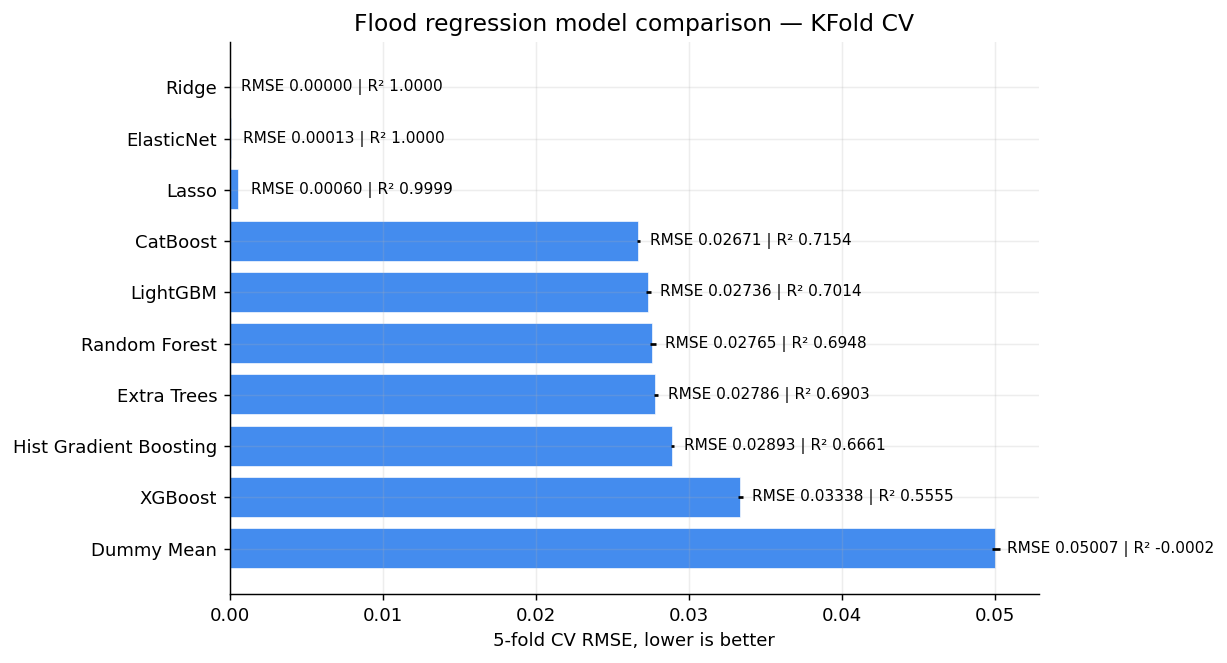

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_regression_fold_rmse_stability.png


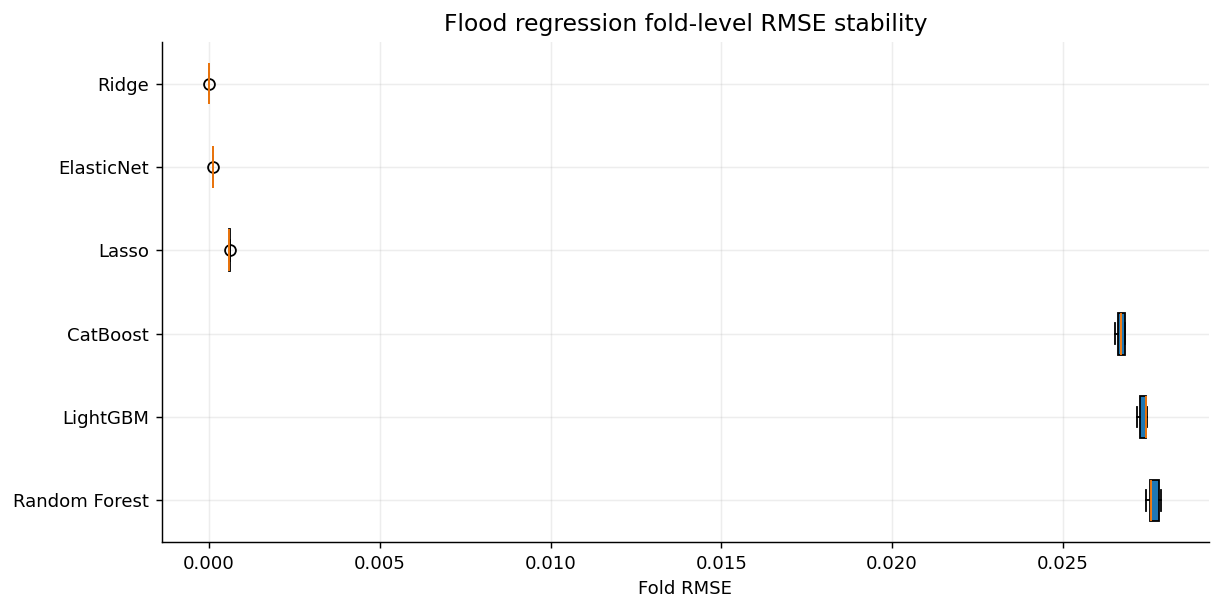

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_actual_vs_predicted.png


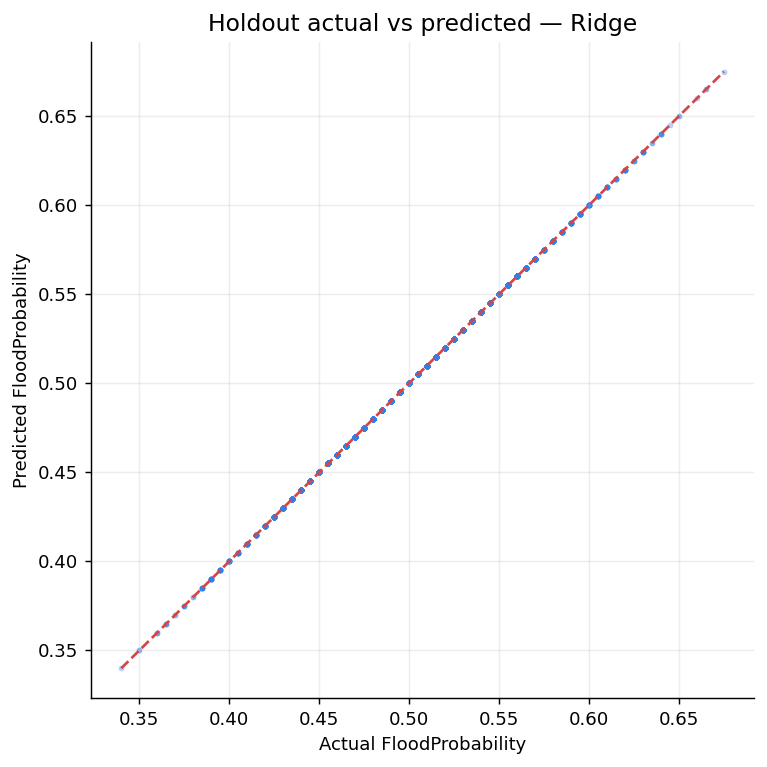

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_target_shuffle_sanity_check.png


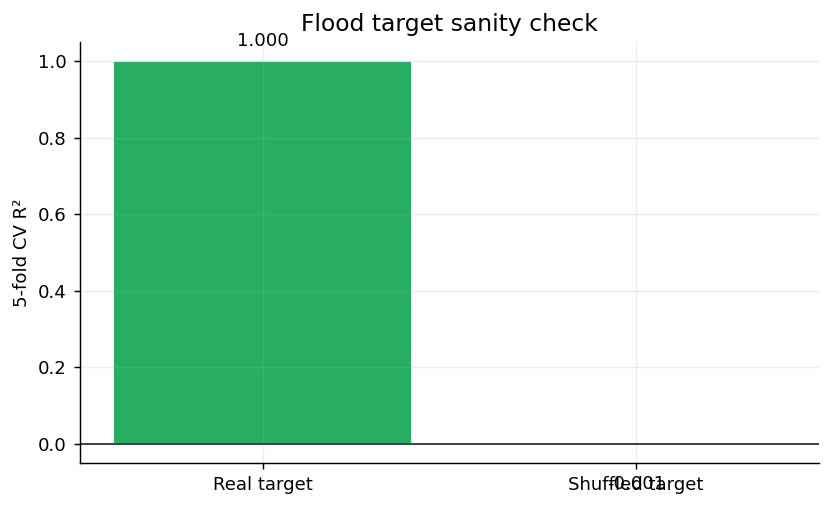

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_flood_feature_importance.png


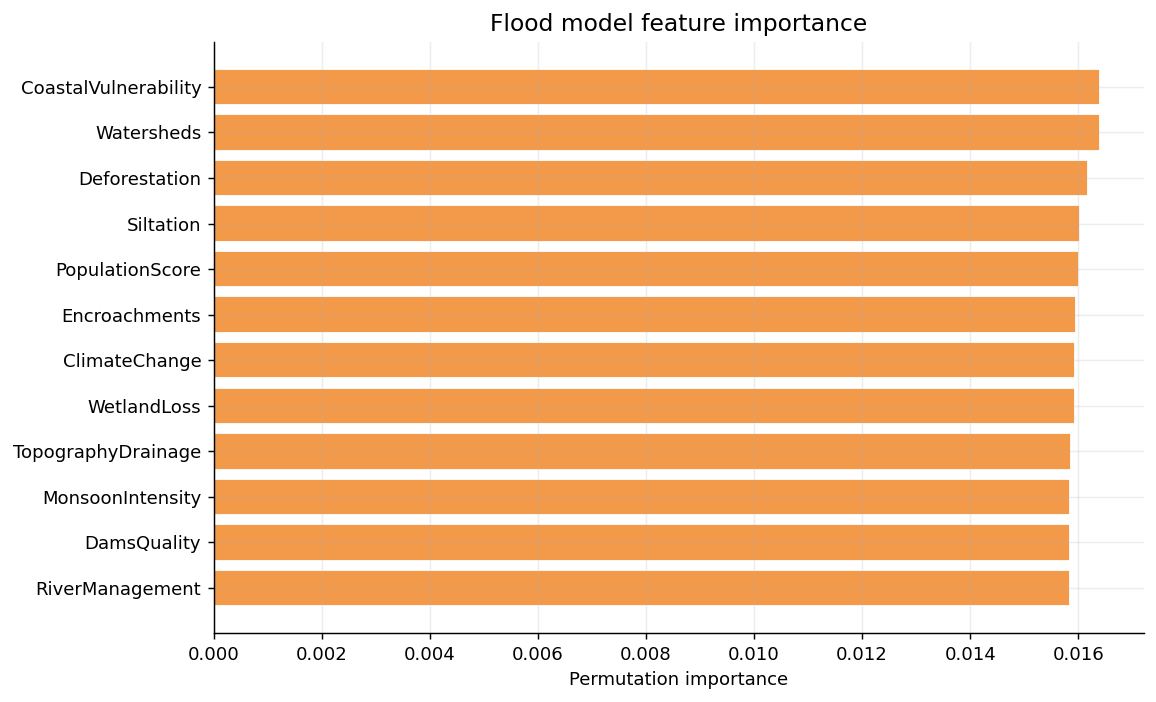

In [22]:
plot = reg_cv.sort_values('rmse_mean', ascending=True)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
bars = ax.barh(plot['model'], plot['rmse_mean'], xerr=plot['rmse_std'], color=COLORS['blue'], edgecolor='white', alpha=.90)
ax.invert_yaxis()
ax.set_xlabel('5-fold CV RMSE, lower is better')
ax.set_title('Flood regression model comparison — KFold CV')
max_rmse = max(plot['rmse_mean'].max(), 1e-9)
for b, r, r2 in zip(bars, plot['rmse_mean'], plot['r2_mean']):
    ax.text(r + max_rmse * 0.015, b.get_y()+b.get_height()/2, f'RMSE {r:.5f} | R² {r2:.4f}', va='center', fontsize=8.5)
savefig('03_flood_regression_cv_ranking.png')
plt.show()

# Fold-level stability view. This makes the KFold behavior explicit.
fold_plot = reg_cv_folds.copy()
top_models_for_folds = reg_cv.head(min(6, len(reg_cv)))['model'].tolist()
fold_plot = fold_plot[fold_plot['model'].isin(top_models_for_folds)]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
positions = np.arange(len(top_models_for_folds))
box_data = [fold_plot.loc[fold_plot['model'].eq(m), 'test_rmse'].values for m in top_models_for_folds]
ax.boxplot(box_data, vert=False, labels=top_models_for_folds, patch_artist=True)
ax.invert_yaxis()
ax.set_xlabel('Fold RMSE')
ax.set_title('Flood regression fold-level RMSE stability')
savefig('03_flood_regression_fold_rmse_stability.png')
plt.show()

sample = pd.DataFrame({'actual': y_test, 'predicted': pred}).sample(min(2500, len(y_test)), random_state=42)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(sample['actual'], sample['predicted'], s=10, alpha=.35, color=COLORS['blue'], lw=0)
lo, hi = min(sample.min()), max(sample.max())
ax.plot([lo,hi],[lo,hi], ls='--', color=COLORS['red'])
ax.set_xlabel('Actual FloodProbability')
ax.set_ylabel('Predicted FloodProbability')
ax.set_title(f'Holdout actual vs predicted — {best_reg_name}')
savefig('03_flood_actual_vs_predicted.png')
plt.show()

# Sanity-check visual: real target vs shuffled target performance.
fig, ax = plt.subplots(figsize=(6.5, 4))
real_r2 = float(reg_cv.loc[reg_cv['model'].eq('Ridge'), 'r2_mean'].iloc[0]) if 'Ridge' in reg_cv['model'].values else float(reg_cv.loc[0, 'r2_mean'])
shuf_r2 = float(flood_target_shuffle_check.loc[0, 'cv_r2_mean'])
bars = ax.bar(['Real target', 'Shuffled target'], [real_r2, shuf_r2], color=[COLORS['green'], COLORS['gray']], edgecolor='white')
ax.axhline(0, color='#333333', lw=1)
ax.set_ylabel('5-fold CV R²')
ax.set_title('Flood target sanity check')
for b, v in zip(bars, [real_r2, shuf_r2]):
    ax.text(b.get_x()+b.get_width()/2, v + (0.03 if v >= 0 else -0.08), f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top')
savefig('03_flood_target_shuffle_sanity_check.png')
plt.show()

# Permutation importance on a sample for interpretability.
imp_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
imp_y = y_test.loc[imp_sample.index]
perm = permutation_importance(best_reg, imp_sample, imp_y, n_repeats=3, random_state=42, n_jobs=1, scoring='neg_root_mean_squared_error')
flood_imp = pd.DataFrame({'feature': FLOOD_FEATURES, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
flood_imp.to_csv(OUTPUT_DIR / '03_flood_feature_importance.csv', index=False)

top = flood_imp.head(12).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top['feature'], top['importance'], color=COLORS['orange'], edgecolor='white')
ax.set_xlabel('Permutation importance')
ax.set_title('Flood model feature importance')
savefig('03_flood_feature_importance.png')
plt.show()

## External data policy in Notebook 03

Open Data Jabar flood-event features are **not used** to train the rice vulnerability classifier. They are carried only as context for Notebook 04 and Notebook 05.

This keeps the rice model aligned with Method 3: financial-operational vulnerability prediction from rice operational features. Regional flood history belongs to hazard/exposure and is applied downstream as a small modifier or tie-breaker.

# Part B — Rice vulnerability classification

In [23]:
rice_model = rice_df[rice_df[RICE_TARGET].isin(LABEL_ORDER)].reset_index(drop=True)

policy_path = OUTPUT_DIR / '02_feature_modeling_policy.csv'
if policy_path.exists():
    feature_policy_df = pd.read_csv(policy_path)
    feature_policy_map = dict(zip(feature_policy_df['column'], feature_policy_df['modeling_policy']))
else:
    feature_policy_df = pd.DataFrame(columns=['column','modeling_policy'])
    feature_policy_map = {}

meta_audit_cols = set(metadata.get('audit_only_columns', []))
meta_admin_cols = set(metadata.get('admin_columns', []))
lf_cols = set(metadata.get('labeling_function_columns', []))
redundant_cols = set(metadata.get('redundant_operational_exclude_columns', [])) | {'rc_ratio'}

EXTERNAL_HAZARD_CONTEXT_COLS = {
    c for c in rice_model.columns
    if c.startswith('flood_events_')
    or c.startswith('historical_flood_')
    or c in {'region_key', 'external_data_coverage', 'source_file_used', 'source_dataset', 'source_url', 'methodological_role'}
}


CLUSTER_AUDIT_COLS = meta_audit_cols | {c for c in rice_model.columns if 'cluster' in c.lower()}
SCORE_COLS = {c for c in rice_model.columns if c.endswith('_score')}
HARD_RULE_FLAGS = {'below_break_even_flag', 'negative_margin_flag'}
LABEL_FUNCTION_COLS = lf_cols | {c for c in rice_model.columns if c.startswith('lf_')}
ADMIN_AND_ID_COLS = meta_admin_cols | {'dmu', 'source_sheet', 'source_row', 'actor_role', 'region_key'}
TARGET_AND_TEXT_COLS = {RICE_TARGET, 'label_reason', 'label_source', 'labeling_function_hits'}

POLICY_EXCLUDE_STATUSES = {
    'target',
    'audit_only_excluded_from_modeling',
    'label_construction_excluded_from_operational',
    'identifier_or_admin_excluded_from_modeling',
    'redundant_inverse_excluded_from_operational',
}
POLICY_EXCLUDED_COLS = {c for c, status in feature_policy_map.items() if status in POLICY_EXCLUDE_STATUSES}

OPERATIONAL_EXCLUDE = (
    TARGET_AND_TEXT_COLS | ADMIN_AND_ID_COLS | CLUSTER_AUDIT_COLS |
    SCORE_COLS | HARD_RULE_FLAGS | LABEL_FUNCTION_COLS | EXTERNAL_HAZARD_CONTEXT_COLS |
    POLICY_EXCLUDED_COLS | redundant_cols |
    {'final_vulnerability_score', 'rule_vulnerability_score'}
)

def valid_feature_list(cols):
    kept = []
    for c in cols:
        if c not in rice_model.columns:
            continue
        s = rice_model[c]
        if s.notna().sum() == 0:
            continue
        if s.nunique(dropna=True) <= 1:
            continue
        kept.append(c)
    return kept

operational_features = valid_feature_list([c for c in rice_model.columns if c not in OPERATIONAL_EXCLUDE])

forbidden_found = sorted(set(operational_features) & (
    CLUSTER_AUDIT_COLS | SCORE_COLS | HARD_RULE_FLAGS | LABEL_FUNCTION_COLS | EXTERNAL_HAZARD_CONTEXT_COLS | EXTERNAL_HAZARD_CONTEXT_COLS |
    {'final_vulnerability_score', 'rule_vulnerability_score', 'label_reason', 'label_source', 'labeling_function_hits'} |
    redundant_cols
))
assert not forbidden_found, f'Operational feature leakage detected: {forbidden_found}'

feature_audit = pd.DataFrame([{
    'mode': 'operational_prediction',
    'n_features': len(operational_features),
    'contains_cluster_feature': any('cluster' in c.lower() for c in operational_features),
    'contains_score_feature': any(c.endswith('_score') for c in operational_features),
    'contains_rc_ratio': 'rc_ratio' in operational_features,
    'contains_external_hazard_context': any(c in EXTERNAL_HAZARD_CONTEXT_COLS for c in operational_features),
    'example_features': ', '.join(operational_features[:15])
}])
display(feature_audit)

,mode,n_features,contains_cluster_feature,contains_score_feature,contains_rc_ratio,contains_external_hazard_context,example_features
0,operational_prediction,34,False,False,False,False,"actor, region, total_cost, output_value, margi..."


In [24]:
def build_clf(Xf, model):
    cat = Xf.select_dtypes(include=['object','category']).columns.tolist()
    num = [c for c in Xf.columns if c not in cat]
    prep = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_onehot())]), cat)
    ], remainder='drop')
    return Pipeline([('prep', prep), ('model', model)])

# Complete classification model zoo. Boosters are optional but kept in Notebook 03.
classifiers = {
    'Dummy Most Frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=None, min_samples_leaf=3, class_weight='balanced_subsample', random_state=42, n_jobs=1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=140, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=80, learning_rate=.06, random_state=42),
}

if RUN_OPTIONAL_BOOSTERS and optional_import('xgboost'):
    from xgboost import XGBClassifier
    classifiers['XGBoost'] = LabelEncodedClassifier(XGBClassifier(
        n_estimators=70, max_depth=4, learning_rate=.05,
        subsample=.90, colsample_bytree=.90,
        objective='multi:softprob', eval_metric='mlogloss',
        random_state=42, n_jobs=1
    ))
if RUN_OPTIONAL_BOOSTERS and optional_import('lightgbm'):
    from lightgbm import LGBMClassifier
    classifiers['LightGBM'] = LGBMClassifier(
        n_estimators=80, learning_rate=.05, num_leaves=31,
        class_weight='balanced', random_state=42, n_jobs=1, verbose=-1
    )
if RUN_OPTIONAL_BOOSTERS and optional_import('catboost'):
    from catboost import CatBoostClassifier
    classifiers['CatBoost'] = LabelEncodedClassifier(CatBoostClassifier(
        iterations=80, learning_rate=.05, depth=6,
        loss_function='MultiClass', verbose=False, random_seed=42, thread_count=1
    ))

print('Rice classification candidates:', list(classifiers.keys()))

y_all = rice_model[RICE_TARGET]
train_idx, test_idx = train_test_split(rice_model.index, test_size=.25, random_state=42, stratify=y_all)
train_df = rice_model.loc[train_idx].reset_index(drop=True)
test_df = rice_model.loc[test_idx].reset_index(drop=True)

RICE_CV_SPLITS = 5
cv = StratifiedKFold(n_splits=RICE_CV_SPLITS, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

rows, fold_rows, pipes = [], [], {}
Xtr = train_df[operational_features]
ytr = train_df[RICE_TARGET]
for name, model in classifiers.items():
    pipe = build_clf(Xtr, model)
    scores = cross_validate(
        pipe, Xtr, ytr, cv=cv, scoring=scoring,
        return_train_score=True,
        n_jobs=1
    )

    for fold_idx in range(RICE_CV_SPLITS):
        fold_rows.append({
            'mode': 'operational_prediction',
            'model': name,
            'fold': fold_idx + 1,
            'test_accuracy': float(scores['test_accuracy'][fold_idx]),
            'test_balanced_accuracy': float(scores['test_balanced_accuracy'][fold_idx]),
            'test_f1_macro': float(scores['test_f1_macro'][fold_idx]),
            'test_f1_weighted': float(scores['test_f1_weighted'][fold_idx]),
            'train_f1_macro': float(scores['train_f1_macro'][fold_idx]),
            'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
        })

    rows.append({
        'mode': 'operational_prediction',
        'model': name,
        'cv_protocol': f'{RICE_CV_SPLITS}-fold StratifiedKFold on training partition',
        'accuracy_mean': float(scores['test_accuracy'].mean()),
        'accuracy_std': float(scores['test_accuracy'].std(ddof=1)),
        'balanced_accuracy_mean': float(scores['test_balanced_accuracy'].mean()),
        'balanced_accuracy_std': float(scores['test_balanced_accuracy'].std(ddof=1)),
        'f1_macro_mean': float(scores['test_f1_macro'].mean()),
        'f1_macro_std': float(scores['test_f1_macro'].std(ddof=1)),
        'f1_weighted_mean': float(scores['test_f1_weighted'].mean()),
        'f1_weighted_std': float(scores['test_f1_weighted'].std(ddof=1)),
        'train_f1_macro_mean': float(scores['train_f1_macro'].mean()),
        'generalization_gap_f1_macro': float(scores['train_f1_macro'].mean() - scores['test_f1_macro'].mean()),
        'n_features': len(operational_features),
        'n_train_rows_used_in_cv': len(Xtr),
        'is_optional_booster': name in {'XGBoost', 'LightGBM', 'CatBoost'}
    })
    pipes[name] = pipe

clf_cv = pd.DataFrame(rows)
clf_cv['selection_score'] = .70 * clf_cv['f1_macro_mean'] + .30 * clf_cv['balanced_accuracy_mean']
clf_cv = clf_cv.sort_values('selection_score', ascending=False).reset_index(drop=True)
clf_cv_folds = pd.DataFrame(fold_rows)

best_clf_name = clf_cv.iloc[0]['model']
best_clf = pipes[best_clf_name]
best_clf.fit(train_df[operational_features], train_df[RICE_TARGET])
test_pred = best_clf.predict(test_df[operational_features])

rice_holdout = pd.DataFrame([{
    'mode': 'operational_prediction',
    'model': best_clf_name,
    'validation_role': 'holdout sanity check after StratifiedKFold selection',
    'accuracy': accuracy_score(test_df[RICE_TARGET], test_pred),
    'balanced_accuracy': balanced_accuracy_score(test_df[RICE_TARGET], test_pred),
    'f1_macro': f1_score(test_df[RICE_TARGET], test_pred, average='macro'),
    'f1_weighted': f1_score(test_df[RICE_TARGET], test_pred, average='weighted'),
    'n_features': len(operational_features)
}])

display(clf_cv)
display(rice_holdout)
print(classification_report(test_df[RICE_TARGET], test_pred))

Rice classification candidates: ['Dummy Most Frequent', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']


,mode,model,cv_protocol,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,train_f1_macro_mean,generalization_gap_f1_macro,n_features,n_train_rows_used_in_cv,is_optional_booster,selection_score
0,operational_prediction,Random Forest,5-fold StratifiedKFold on training partition,0.998305,0.003790,0.998374,0.003636,0.996002,0.008939,0.998335,0.003723,0.997863,0.001861,34,590,False,0.996714
1,operational_prediction,Decision Tree,5-fold StratifiedKFold on training partition,0.993220,0.007090,0.989101,0.014191,0.983958,0.016366,0.993336,0.006892,0.995702,0.011744,34,590,False,0.985501
2,operational_prediction,LightGBM,5-fold StratifiedKFold on training partition,0.993220,0.007090,0.982674,0.017651,0.983553,0.016514,0.993254,0.006918,1.000000,0.016447,34,590,True,0.983289
3,operational_prediction,CatBoost,5-fold StratifiedKFold on training partition,0.993220,0.007090,0.982674,0.017651,0.983553,0.016514,0.993254,0.006918,0.998987,0.015435,34,590,True,0.983289
4,operational_prediction,Hist Gradient Boosting,5-fold StratifiedKFold on training partition,0.991525,0.011985,0.986829,0.021544,0.980280,0.028036,0.991727,0.011728,1.000000,0.019720,34,590,False,0.982245
5,operational_prediction,XGBoost,5-fold StratifiedKFold on training partition,0.991525,0.008475,0.976007,0.028294,0.978870,0.021028,0.991446,0.008533,1.000000,0.021130,34,590,True,0.978011
6,operational_prediction,Extra Trees,5-fold StratifiedKFold on training partition,0.927119,0.033686,0.897006,0.042110,0.859577,0.052328,0.933195,0.028223,0.951783,0.092206,34,590,False,0.870806
7,operational_prediction,Logistic Regression,5-fold StratifiedKFold on training partition,0.588136,0.050351,0.554719,0.070044,0.521161,0.047613,0.637930,0.063445,0.551120,0.029959,34,590,False,0.531229
8,operational_prediction,Dummy Most Frequent,5-fold StratifiedKFold on training partition,0.571186,0.004642,0.333333,0.000000,0.242356,0.001252,0.415305,0.005527,0.242359,0.000003,34,590,False,0.269649


,mode,model,validation_role,accuracy,balanced_accuracy,f1_macro,f1_weighted,n_features
0,operational_prediction,Random Forest,holdout sanity check after StratifiedKFold sel...,0.989848,0.974265,0.975229,0.98984,34


                      precision    recall  f1-score   support

  High Vulnerability       1.00      0.99      0.99        68
   Low Vulnerability       0.99      1.00      1.00       113
Medium Vulnerability       0.94      0.94      0.94        16

            accuracy                           0.99       197
           macro avg       0.98      0.97      0.98       197
        weighted avg       0.99      0.99      0.99       197



saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_classification_cv_comparison.png


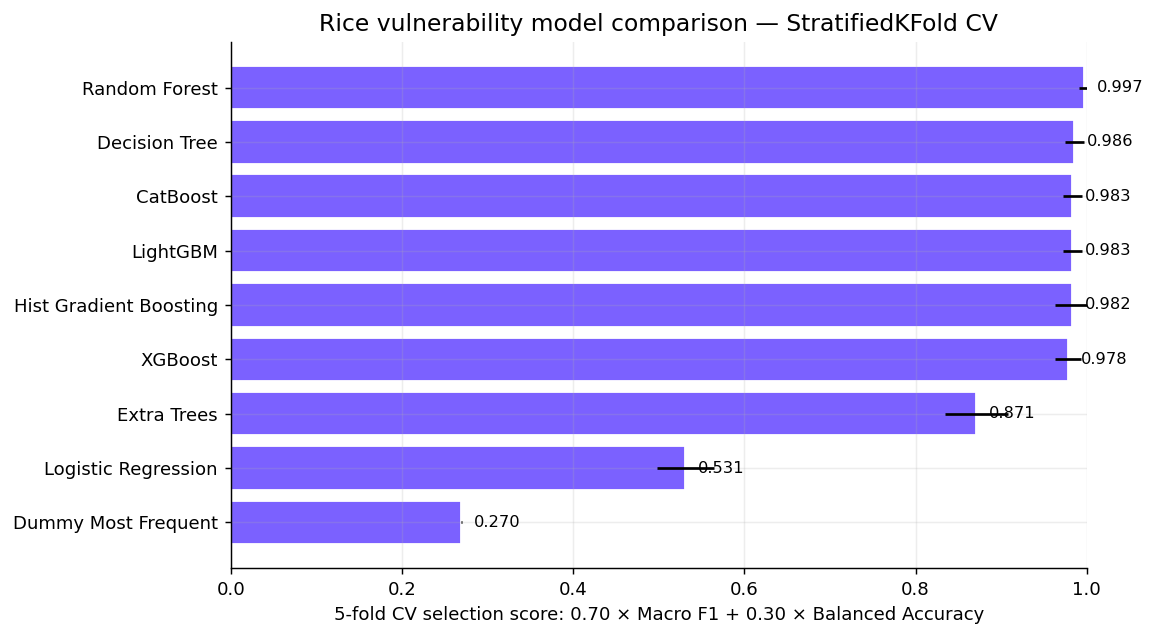

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_classification_fold_f1_stability.png


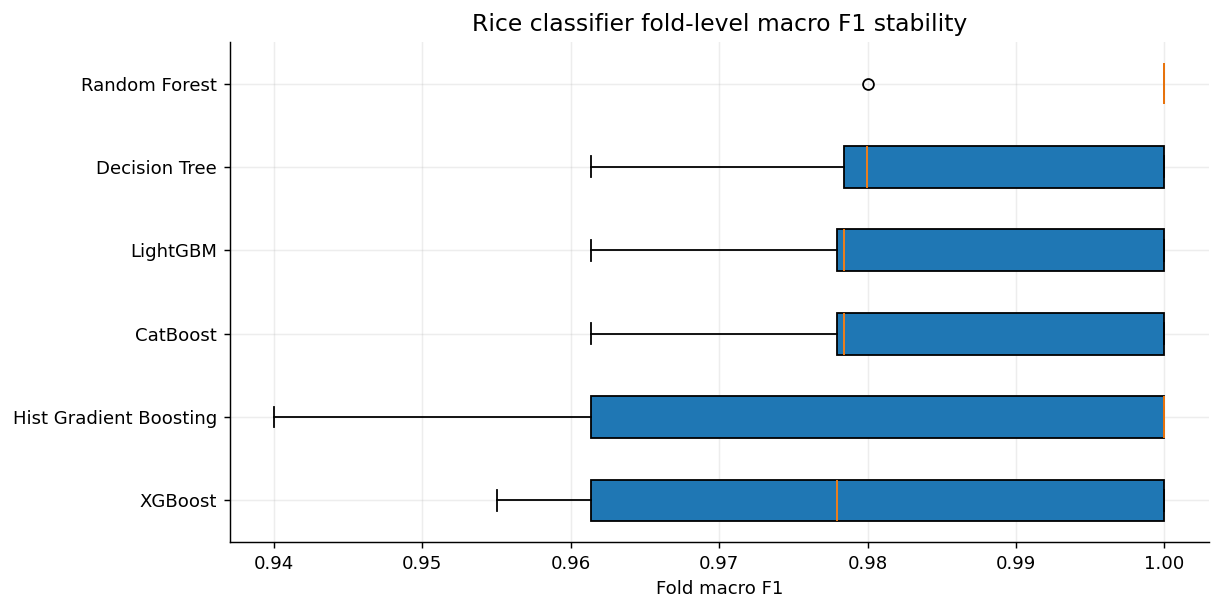

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_operational_confusion_matrix.png


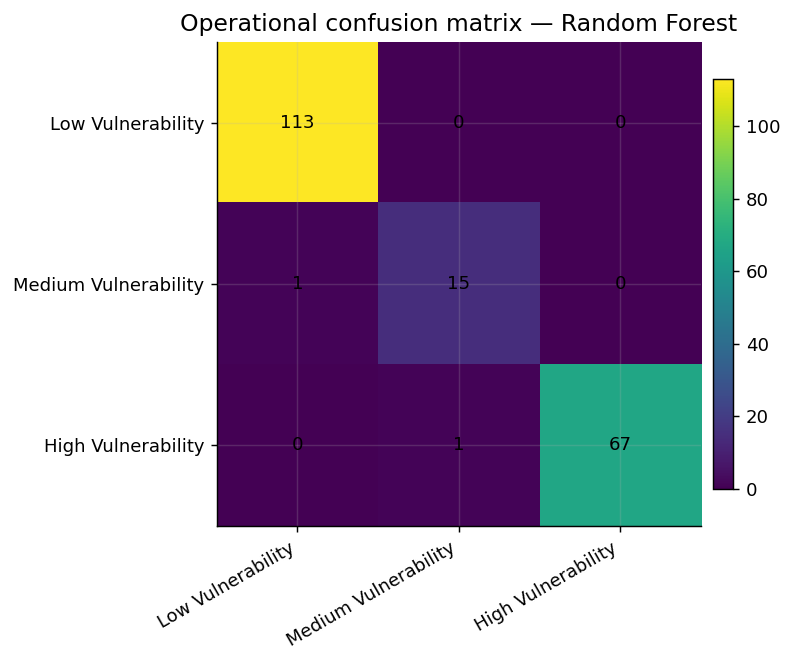

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_feature_importance.png


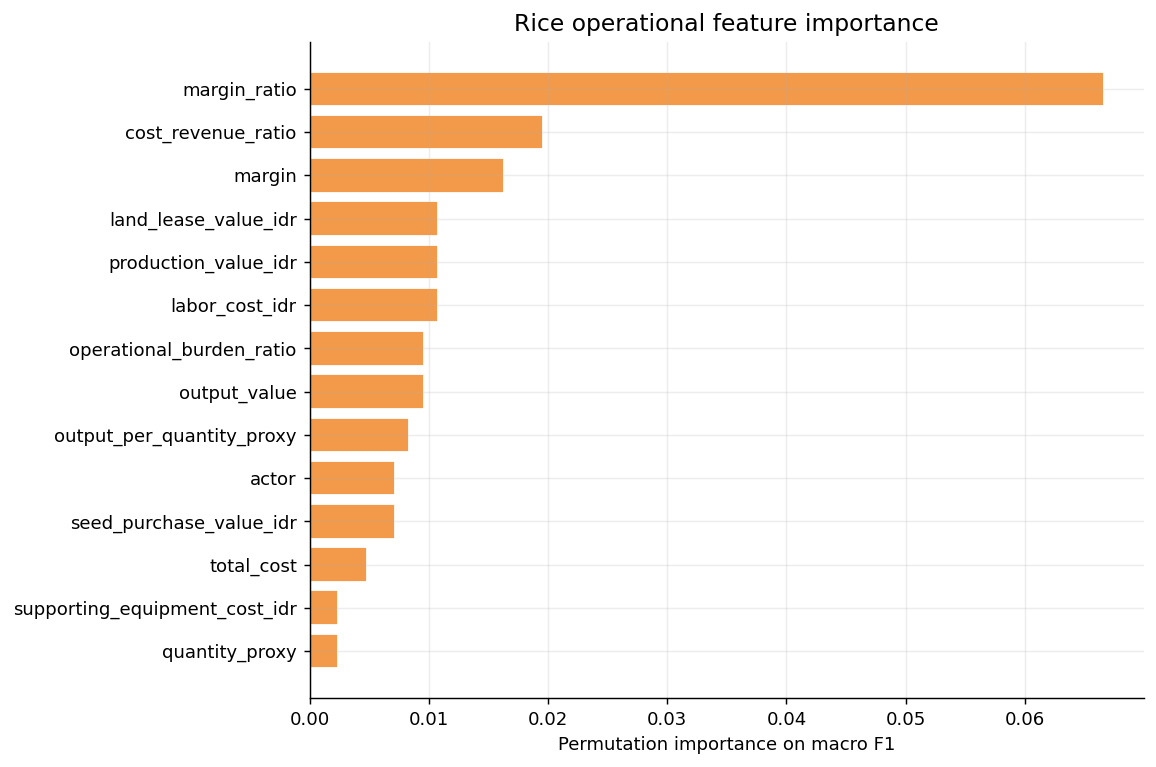

In [25]:
plot = clf_cv.sort_values('selection_score', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot['model'], plot['selection_score'], xerr=0.70 * plot['f1_macro_std'].fillna(0), color=COLORS['purple'], edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('5-fold CV selection score: 0.70 × Macro F1 + 0.30 × Balanced Accuracy')
ax.set_title('Rice vulnerability model comparison — StratifiedKFold CV')
for b, v in zip(bars, plot['selection_score']):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
savefig('03_rice_classification_cv_comparison.png')
plt.show()

# Fold-level stability view for top models.
top_clf_models = clf_cv.head(min(6, len(clf_cv)))['model'].tolist()
fold_plot = clf_cv_folds[clf_cv_folds['model'].isin(top_clf_models)]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
box_data = [fold_plot.loc[fold_plot['model'].eq(m), 'test_f1_macro'].values for m in top_clf_models]
ax.boxplot(box_data, vert=False, labels=top_clf_models, patch_artist=True)
ax.invert_yaxis()
ax.set_xlabel('Fold macro F1')
ax.set_title('Rice classifier fold-level macro F1 stability')
savefig('03_rice_classification_fold_f1_stability.png')
plt.show()

cm = confusion_matrix(test_df[RICE_TARGET], test_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(cm)
ax.set_xticks(range(len(LABEL_ORDER))); ax.set_xticklabels(LABEL_ORDER, rotation=30, ha='right')
ax.set_yticks(range(len(LABEL_ORDER))); ax.set_yticklabels(LABEL_ORDER)
ax.set_title(f'Operational confusion matrix — {best_clf_name}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
savefig('03_rice_operational_confusion_matrix.png')
plt.show()

perm = permutation_importance(
    best_clf, test_df[operational_features], test_df[RICE_TARGET],
    n_repeats=10, random_state=42, n_jobs=1, scoring='f1_macro'
)
rice_imp = pd.DataFrame({'feature': operational_features, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
rice_imp.to_csv(OUTPUT_DIR / '03_rice_feature_importance.csv', index=False)

top = rice_imp.head(14).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'], top['importance'], color=COLORS['orange'], edgecolor='white')
ax.set_xlabel('Permutation importance on macro F1')
ax.set_title('Rice operational feature importance')
savefig('03_rice_feature_importance.png')
plt.show()

## 2C. Model selection rationale and error analysis

Notebook 03 is now **modelling-only**, but it still needs to explain why selected models are used and whether errors are concentrated in specific actor or region groups. This protects the analysis from being only a metric table and keeps the modelling tied to the business problem.

,task,selected_model,selection_metric,holdout_summary,main_caution
0,FloodProbability regression,Ridge,"Lowest 5-fold KFold CV RMSE, checked on holdou...",RMSE=0.00000; R2=1.00000,Flood dataset target is tabular and may be str...
1,Rice vulnerability classification,Random Forest,5-fold StratifiedKFold score: 0.70 × Macro F1 ...,MacroF1=0.97523; BalancedAcc=0.97426,"Target is a paper-grounded pseudo-label, not e..."


,actor,n_holdout,error_rate
0,Farmer,95,0.021053
1,Middlemen,30,0.000000
2,Retail,25,0.000000
3,Rice Miller,27,0.000000
4,Wholesaler,20,0.000000


,region,n_holdout,error_rate
0,Garut,47,0.021277
4,Tasikmalaya,50,0.020000
1,Indramayu,35,0.000000
2,Karawang,29,0.000000
3,Subang,36,0.000000


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\03_rice_error_by_actor.png


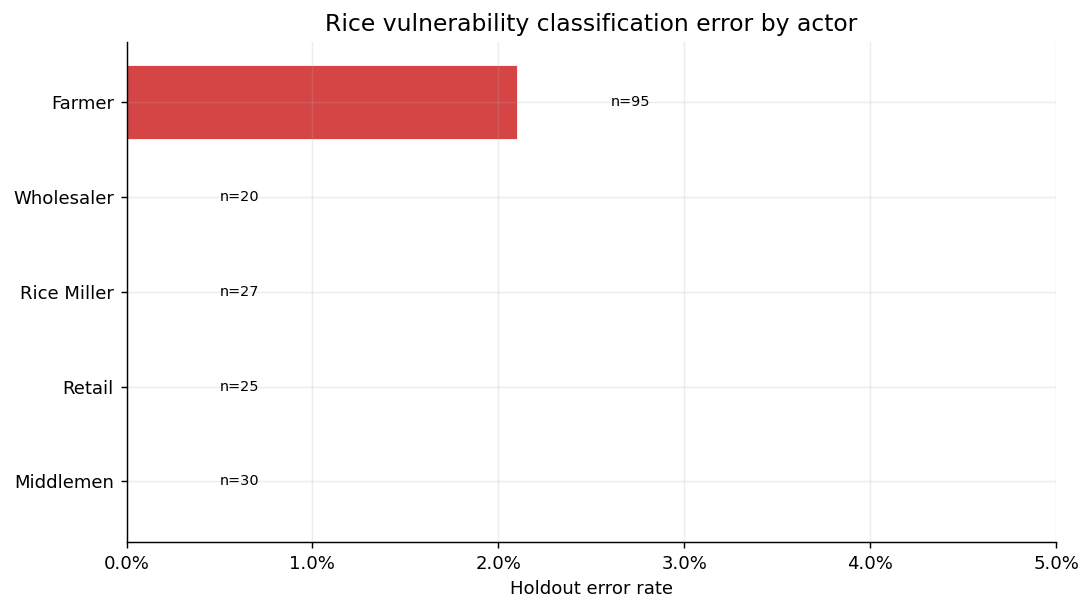

,actor,region,vulnerability_label,predicted_vulnerability_label,cost_revenue_ratio,margin,operational_burden_ratio,label_reason
0,Farmer,Garut,High Vulnerability,Medium Vulnerability,0.984597,126000.0,0.700489,Thin R/C buffer; Thin margin buffer; Far from ...
1,Farmer,Tasikmalaya,Medium Vulnerability,Low Vulnerability,0.864086,1949000.0,0.620990,Far from actor frontier


In [26]:
# Model selection rationale.
model_selection_rationale = pd.DataFrame([
    {
        'task': 'FloodProbability regression',
        'selected_model': best_reg_name,
        'selection_metric': 'Lowest 5-fold KFold CV RMSE, checked on holdout RMSE/R2 and shuffled-target sanity check',
        'holdout_summary': f"RMSE={float(flood_holdout['rmse'].iloc[0]):.5f}; R2={float(flood_holdout['r2'].iloc[0]):.5f}",
        'main_caution': f"Flood dataset target is tabular and may be strongly formula-like; Ridge shuffled-target R2={float(flood_target_shuffle_check['cv_r2_mean'].iloc[0]):.3f}."
    },
    {
        'task': 'Rice vulnerability classification',
        'selected_model': best_clf_name,
        'selection_metric': '5-fold StratifiedKFold score: 0.70 × Macro F1 + 0.30 × Balanced Accuracy',
        'holdout_summary': f"MacroF1={float(rice_holdout['f1_macro'].iloc[0]):.5f}; BalancedAcc={float(rice_holdout['balanced_accuracy'].iloc[0]):.5f}",
        'main_caution': 'Target is a paper-grounded pseudo-label, not external field ground truth.'
    }
])
model_selection_rationale.to_csv(OUTPUT_DIR / '03_model_selection_rationale.csv', index=False)
display(model_selection_rationale)

# Build audit dataframe for rice holdout prediction errors.
holdout_audit_cols = [
    'actor', 'region', 'dmu', RICE_TARGET, 'label_reason',
    'total_cost', 'output_value', 'margin', 'cost_revenue_ratio',
    'operational_burden_ratio', 'margin_ratio'
]
holdout_audit_cols = [c for c in holdout_audit_cols if c in test_df.columns]
error_audit = test_df[holdout_audit_cols].copy()
error_audit['predicted_vulnerability_label'] = test_pred
error_audit['is_error'] = error_audit[RICE_TARGET].ne(error_audit['predicted_vulnerability_label'])
error_audit.to_csv(OUTPUT_DIR / '03_rice_holdout_prediction_audit.csv', index=False)

# Error rate by actor and region.
error_by_actor = (
    error_audit.groupby('actor', dropna=False)
    .agg(n_holdout=('actor', 'size'), error_rate=('is_error', 'mean'))
    .reset_index()
    .sort_values('error_rate', ascending=False)
)
error_by_region = (
    error_audit.groupby('region', dropna=False)
    .agg(n_holdout=('region', 'size'), error_rate=('is_error', 'mean'))
    .reset_index()
    .sort_values('error_rate', ascending=False)
)
error_by_actor.to_csv(OUTPUT_DIR / '03_rice_error_by_actor.csv', index=False)
error_by_region.to_csv(OUTPUT_DIR / '03_rice_error_by_region.csv', index=False)
display(error_by_actor)
display(error_by_region)

# Focused visual: actor-level error concentration.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_err = error_by_actor.sort_values('error_rate')
bars = ax.barh(plot_err['actor'], plot_err['error_rate'], color=COLORS['red'], edgecolor='white')
ax.set_xlim(0, max(0.05, plot_err['error_rate'].max() * 1.25))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Holdout error rate')
ax.set_title('Rice vulnerability classification error by actor')
for b, n in zip(bars, plot_err['n_holdout']):
    ax.text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f'n={int(n)}', va='center', fontsize=8)
savefig('03_rice_error_by_actor.png')
plt.show()

# Top disagreement examples for audit.
disagreement_cols = [
    'actor', 'region', RICE_TARGET, 'predicted_vulnerability_label',
    'cost_revenue_ratio', 'margin', 'operational_burden_ratio', 'label_reason'
]
disagreement_cols = [c for c in disagreement_cols if c in error_audit.columns]
disagreements = error_audit[error_audit['is_error']].copy()
if not disagreements.empty:
    disagreements = disagreements.sort_values(['actor', 'region']).reset_index(drop=True)
    disagreements[disagreement_cols].head(30).to_csv(OUTPUT_DIR / '03_rice_prediction_disagreements_top30.csv', index=False)
    display(disagreements[disagreement_cols].head(30))
else:
    pd.DataFrame(columns=disagreement_cols).to_csv(OUTPUT_DIR / '03_rice_prediction_disagreements_top30.csv', index=False)
    print('No holdout disagreements found for the selected rice model.')

## 3. Export final models and transition files

In [27]:
# Final artifacts use the fitted holdout-selected models to keep runtime stable.
# They are sufficient for transition predictions used by Notebook 04 and 05.
final_flood = best_reg
joblib.dump(final_flood, MODEL_DIR / '03_final_flood_probability_model.joblib')

final_rice = best_clf
joblib.dump(final_rice, MODEL_DIR / '03_final_rice_vulnerability_model.joblib')

# Flood full predictions.
flood_full = flood_df.copy()
flood_full['predicted_FloodProbability'] = np.clip(final_flood.predict(flood_df[FLOOD_FEATURES]), 0, 1)
q33, q66 = flood_full['predicted_FloodProbability'].quantile([1/3, 2/3])
flood_full['predicted_flood_risk_level'] = pd.cut(
    flood_full['predicted_FloodProbability'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Low', 'Medium', 'High']
).astype(str)
flood_full.to_csv(OUTPUT_DIR / '03_flood_full_predictions.csv', index=False)

flood_scenario_summary = (
    flood_full.groupby('predicted_flood_risk_level')
    .agg(
        n_scenarios=('predicted_FloodProbability', 'size'),
        min_predicted_probability=('predicted_FloodProbability', 'min'),
        median_predicted_probability=('predicted_FloodProbability', 'median'),
        max_predicted_probability=('predicted_FloodProbability', 'max')
    )
    .reset_index()
    .rename(columns={'predicted_flood_risk_level':'flood_scenario'})
)
flood_scenario_summary.to_csv(OUTPUT_DIR / '03_flood_scenario_summary.csv', index=False)

# Rice full predictions and probabilities.
transition_cols = [
    'actor', 'region', 'region_key', 'dmu', RICE_TARGET, 'label_reason',
    'total_cost', 'output_value', 'margin',
    'cost_revenue_ratio', 'operational_burden_ratio', 'margin_ratio',
    'operational_cost', 'quantity_proxy',
    'precipitation_quality_pct', 'total_precipitation_pct',
    'final_vulnerability_score',
    'flood_events_total', 'flood_events_mean_annual', 'flood_events_recent_5y',
    'flood_events_max_yearly', 'flood_events_trend_slope',
    'historical_flood_exposure_score', 'historical_flood_exposure_level',
    'external_data_coverage', 'source_file_used'
]
transition_cols = [c for c in transition_cols if c in rice_model.columns]
rice_full = rice_model[transition_cols].copy()
rice_full['predicted_vulnerability_label'] = final_rice.predict(rice_model[operational_features])

if hasattr(final_rice, 'predict_proba'):
    proba = final_rice.predict_proba(rice_model[operational_features])
    for idx, cls in enumerate(final_rice.classes_):
        safe_cls = str(cls).lower().replace(' ', '_').replace('/', '_')
        rice_full[f'predicted_proba_{safe_cls}'] = proba[:, idx]

rice_full.to_csv(OUTPUT_DIR / '03_rice_full_predictions.csv', index=False)

# Actor-region summary for stress test and decision support.
agg_spec = {'n_units': ('actor', 'size')}
for col, alias in [
    ('total_cost', 'median_total_cost'),
    ('output_value', 'median_revenue'),
    ('margin', 'median_margin'),
    ('cost_revenue_ratio', 'median_cost_revenue_ratio'),
    ('operational_burden_ratio', 'median_operational_burden_ratio'),
    ('margin_ratio', 'median_margin_ratio'),
    ('final_vulnerability_score', 'median_vulnerability_score')
]:
    if col in rice_full.columns:
        agg_spec[alias] = (col, 'median')

actor_region_summary = rice_full.groupby(['region', 'actor'], dropna=False).agg(**agg_spec).reset_index()
actor_region_summary['dominant_true_vulnerability_label'] = rice_full.groupby(['region','actor'])[RICE_TARGET].apply(mode_or_unknown).values
actor_region_summary['dominant_predicted_vulnerability_label'] = rice_full.groupby(['region','actor'])['predicted_vulnerability_label'].apply(mode_or_unknown).values
actor_region_summary['predicted_high_vulnerability_share'] = (
    rice_full.assign(_high=rice_full['predicted_vulnerability_label'].eq('High Vulnerability').astype(float))
    .groupby(['region','actor'])['_high'].mean().values
)
actor_region_summary['true_high_vulnerability_share'] = (
    rice_full.assign(_high=rice_full[RICE_TARGET].eq('High Vulnerability').astype(float))
    .groupby(['region','actor'])['_high'].mean().values
)
if 'predicted_proba_high_vulnerability' in rice_full.columns:
    actor_region_summary['median_predicted_proba_high'] = rice_full.groupby(['region','actor'])['predicted_proba_high_vulnerability'].median().values

# Stable region key for downstream external-bridge joins.
def normalize_region_key_local(x):
    x = str(x).upper().strip()
    x = x.replace('KABUPATEN ', '').replace('KOTA ', '')
    return ' '.join(x.split())

if 'region_key' not in actor_region_summary.columns:
    actor_region_summary['region_key'] = actor_region_summary['region'].map(normalize_region_key_local)

# Carry external bridge context for downstream Notebook 04/05, but do not train on it.
external_context_cols = [
    'region', 'region_key', 'flood_events_total', 'flood_events_mean_annual', 'flood_events_recent_5y',
    'flood_events_max_yearly', 'flood_events_trend_slope', 'historical_flood_exposure_score',
    'historical_flood_exposure_level', 'external_data_coverage', 'source_file_used'
]
external_context_cols = [c for c in external_context_cols if c in rice_full.columns]
if 'region_key' in external_context_cols:
    context = rice_full[external_context_cols].drop_duplicates(['region', 'region_key'])
    actor_region_summary = actor_region_summary.merge(context.drop(columns=['region'], errors='ignore'), on='region_key', how='left')

actor_region_summary.to_csv(OUTPUT_DIR / '03_actor_region_model_summary.csv', index=False)

# Metrics and artifacts.
reg_cv.to_csv(OUTPUT_DIR / '03_flood_cv_results.csv', index=False)
reg_cv_folds.to_csv(OUTPUT_DIR / '03_flood_cv_fold_results.csv', index=False)
flood_target_shuffle_check.to_csv(OUTPUT_DIR / '03_flood_target_shuffle_sanity_check.csv', index=False)
flood_target_audit.to_csv(OUTPUT_DIR / '03_flood_target_structure_audit.csv', index=False)
flood_holdout.to_csv(OUTPUT_DIR / '03_flood_holdout_metrics.csv', index=False)
clf_cv.to_csv(OUTPUT_DIR / '03_rice_cv_results.csv', index=False)
clf_cv_folds.to_csv(OUTPUT_DIR / '03_rice_cv_fold_results.csv', index=False)
rice_holdout.to_csv(OUTPUT_DIR / '03_rice_holdout_metrics.csv', index=False)
pd.DataFrame({'operational_feature': operational_features}).to_csv(OUTPUT_DIR / '03_operational_feature_list.csv', index=False)
pd.DataFrame({'excluded_from_operational': sorted([c for c in OPERATIONAL_EXCLUDE if c in rice_model.columns])}).to_csv(OUTPUT_DIR / '03_operational_excluded_features.csv', index=False)

summary = {
    'best_flood_regression_model': best_reg_name,
    'flood_regression_candidates': list(regressors.keys()),
    'best_rice_operational_model': best_clf_name,
    'rice_classification_candidates': list(classifiers.keys()),
    'flood_holdout': flood_holdout.to_dict('records')[0],
    'rice_operational_holdout': rice_holdout.to_dict('records')[0],
    'rice_operational_n_features': len(operational_features),
    'rice_operational_uses_cluster_features': any('cluster' in c.lower() for c in operational_features),
    'rice_operational_uses_score_features': any(c.endswith('_score') for c in operational_features),
    'notebook_scope': 'model_training_only',
    'boosting_models_retained_in_notebook_03': True,
    'validation_protocol': {
        'flood_regression': f'{FLOOD_CV_SPLITS}-fold KFold on training partition + holdout sanity check + shuffled-target sanity check',
        'rice_classification': f'{RICE_CV_SPLITS}-fold StratifiedKFold on training partition + holdout sanity check'
    },
    'transition_outputs': [
        '03_flood_full_predictions.csv',
        '03_flood_scenario_summary.csv',
        '03_flood_cv_fold_results.csv',
        '03_flood_target_shuffle_sanity_check.csv',
        '03_rice_full_predictions.csv',
        '03_actor_region_model_summary.csv',
        '03_rice_cv_fold_results.csv'
    ],
    'next_notebooks': {
        '04': 'Method 5 stress-test sensitivity analysis',
        '05': 'Method 1 hazard-vulnerability decision support'
    }
}
json.dump(summary, open(OUTPUT_DIR / '03_final_model_summary.json', 'w'), indent=2)
json.dump(summary, open(OUTPUT_DIR / '03_model_transition_manifest.json', 'w'), indent=2)

print(json.dumps(summary, indent=2))
print('Saved transition outputs:')
for p in summary['transition_outputs']:
    print('-', p, (OUTPUT_DIR / p).exists())

{
  "best_flood_regression_model": "Ridge",
  "flood_regression_candidates": [
    "Dummy Mean",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "Random Forest",
    "Extra Trees",
    "Hist Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
  ],
  "best_rice_operational_model": "Random Forest",
  "rice_classification_candidates": [
    "Dummy Most Frequent",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Hist Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
  ],
  "flood_holdout": {
    "model": "Ridge",
    "validation_role": "holdout sanity check after KFold selection",
    "mae": 1.790161049403377e-06,
    "rmse": 2.2428357943190447e-06,
    "r2": 0.9999999979802693
  },
  "rice_operational_holdout": {
    "mode": "operational_prediction",
    "model": "Random Forest",
    "validation_role": "holdout sanity check after StratifiedKFold selection",
    "accuracy": 0.9898477157360406,
    "balanced_accuracy"